# Direct alignment: experiment planes to mapzebrain

This notebook aligns functional planes from each experiment fish directly to mapzebrain planes (without first aligning to a separate reference fish brain).

In [1]:
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, '/Users/elysiaye/alignment')

from alignment import caiman_memmap_reader, minmax_scaler
from registration import sitkalignment

cv2 not available


# Step 1: Align a single experiment plane to mapzebrain atlas plane

Establish data folder and experiment folder

In [2]:
# Optional quick setup (main config is in the dedicated config cell below)
data_folder = Path('/Volumes/Kobi/DOI_animals_good')
fish_name = 'elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925'

Select plane for alignment

In [3]:
# experiment fish plane of interest (from experiment folder targets)
# Use 0 for the first / plane-0 functional target; set to None to auto-pick the first available key.
# Tuning: change if you want another plane; must exist in printed list after the memmap-loading cell runs.
selected_plane = 0

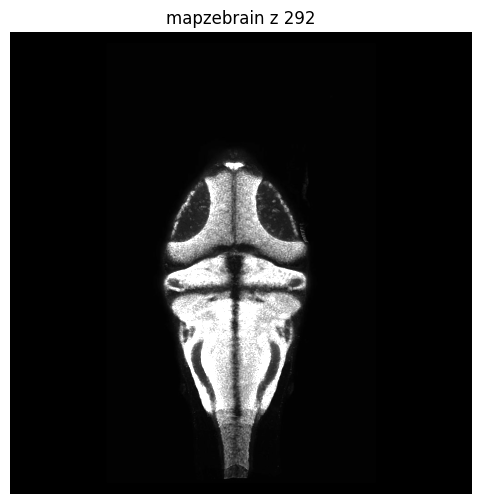

In [3]:
# mapzebrain plane preview (self-contained)
# Tuning: if global alignment is "almost" but A/P or midline is off, try adjacent slices (±1–2).
selected_mapzebrain_z = 292
mapzebrain_img_path = Path(r'./reference_images/hindbrain/mapzebrain/T_AVG_HuCD.tif')

# Load stack here so this cell can run independently.
_source_stack = tifffile.imread(str(mapzebrain_img_path))
if not (0 <= selected_mapzebrain_z < _source_stack.shape[0]):
    raise ValueError(
        f'selected_mapzebrain_z={selected_mapzebrain_z} out of range for stack with '
        f'{_source_stack.shape[0]} slices'
    )

source_img = _source_stack[selected_mapzebrain_z, :, :]
source_img = sitkalignment.embed_image(source_img, 1024)  # matching image sizes to 1024x1024

max_val = float(source_img.max())
if max_val > 0:
    source_img = source_img / max_val  # rescaling pixel brightness --> this is normalizing the image so the new maximum is 1 and everything else is scaled down proportionally
source_img *= 2**10 # mutipling by 2^10 aka 1024

plt.figure(figsize=(6, 6))
# Tuning: display only; does not affect registration. Change vmax to see dim structure.
plt.imshow(source_img, cmap='gray', vmax=700)
plt.title(f'mapzebrain z {selected_mapzebrain_z}')
plt.axis('off')
plt.show()

In [8]:
# Pick experiment folder for target planes (mesmerize-batch).
#
# Requires: `data_folder`, optional `fish_name`. Run the mapzebrain preview cell first
# so `source_img` exists. Later cells use `selected_plane` and build the target view.

if "source_img" not in globals():
    raise ValueError("Run the mapzebrain preview cell first so `source_img` is available.")

exp_candidates = sorted(
    [p for p in Path(data_folder).iterdir() if p.is_dir() and "mesmerize-batch" in {x.name for x in p.iterdir()}],
    key=lambda p: p.name,
)
if len(exp_candidates) == 0:
    raise ValueError(f"No experiment folders with 'mesmerize-batch' found in {data_folder}")

if fish_name:
    matches = [p for p in exp_candidates if fish_name in p.name]
    if len(matches) == 0:
        raise ValueError(f"No experiment folder matching fish_name='{fish_name}'")
    if len(matches) > 1:
        print(f"Multiple matches for '{fish_name}', using first: {matches[0].name}")
    exp_folder = matches[0]
else:
    exp_folder = exp_candidates[0]

print(f"Using experiment folder: {exp_folder}")


Using experiment folder: /Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925


In [6]:
# Requires: `exp_folder` from the previous cell.

# Load batch metadata and build uuid → plane map
batch_path = exp_folder / "mesmerize-batch" / "batch.pickle"
if not batch_path.exists():
    raise ValueError(f"Missing batch file: {batch_path}")

df_batch = pd.read_pickle(batch_path)
if "algo" in df_batch.columns:
    df_batch = df_batch[df_batch["algo"] == "mcorr"]

uuid_to_plane = {}
plane_col = None
for candidate in ["plane", "z", "z_plane", "slice", "plane_idx", "plane_index"]:
    if candidate in df_batch.columns:
        plane_col = candidate
        break

if plane_col is not None:
    uuid_to_plane.update({
        str(row.uuid): int(row[plane_col])
        for _, row in df_batch[["uuid", plane_col]].dropna().iterrows()
    })

for _, row in df_batch.iterrows():
    uid = str(row.uuid)
    if uid in uuid_to_plane:
        continue
    for field in ["item_name", "input_movie_path"]:
        if field in df_batch.columns:
            m = re.search(r"img_stack[_\-\s]?(\d+)", str(row[field]), flags=re.IGNORECASE)
            if m:
                uuid_to_plane[uid] = int(m.group(1))
                break


In [7]:
# Scan mesmerize-batch for motion-corrected .mmap files (no memmap reads yet)
#
# Requires: `exp_folder`, `df_batch`, `uuid_to_plane`.
filenames = set(df_batch.uuid.astype(str)) if "uuid" in df_batch.columns else set()
target_items = []  # (mmap_path, detected_plane, uuid)

with os.scandir(exp_folder / "mesmerize-batch") as entries:
    for entry in entries:
        if not entry.is_dir():
            continue
        if filenames and entry.name not in filenames:
            continue
        with os.scandir(entry.path) as subentries:
            for subentry in subentries:
                if not subentry.name.endswith(".mmap") or subentry.name.startswith("._"):
                    continue

                detected_plane = uuid_to_plane.get(entry.name)
                if detected_plane is None:
                    m = re.search(
                        r"(?:^|[_\-\s])(plane|z|slice|img_stack)[_\-\s]?(\d+)(?:[_\-\s]|$)",
                        subentry.path,
                        flags=re.IGNORECASE,
                    )
                    if m:
                        detected_plane = int(m.group(2))

                target_items.append((subentry.path, detected_plane, entry.name))

if len(target_items) == 0:
    raise ValueError("No target .mmap files found in experiment folder.")

target_items.sort(
    key=lambda x: (
        x[1] is None,
        x[1] if x[1] is not None else 10**9,
        x[2],
        x[0],
    )
)

planes_from_scan = sorted({p for _, p, _ in target_items if p is not None})


In [8]:
# Load std-projection target images; set `plane` and `plot_img`.
#
# Requires: `target_items`, `planes_from_scan`, and global `selected_plane`.

def _std_plane_image(img_path):
    img_stack = caiman_memmap_reader(img_path, mode="r")
    target_img = np.nanstd(img_stack, axis=0)
    max_val = float(target_img.max())
    if max_val > 0:
        target_img = target_img / max_val
    target_img *= 2**10
    target_img = np.rot90(target_img, k=1)
    target_img = sitkalignment.embed_image(target_img, 1024)
    return target_img


target_img_by_plane = {}
plane_to_uuid = {}

_sort_key = lambda x: (
    x[1] is None,
    x[1] if x[1] is not None else 10**9,
    x[2],
    x[0],
)

if selected_plane is not None:
    want = selected_plane
    matches = [t for t in target_items if t[1] == want]
    if len(matches) == 0:
        raise ValueError(
            f"No .mmap matched plane={want} from batch/path metadata. "
            f"Planes seen in scan: {planes_from_scan}"
        )
    matches.sort(key=_sort_key)
    _path, _, _uid = matches[0]
    target_img_by_plane[want] = _std_plane_image(_path)
    plane_to_uuid[want] = _uid
elif len(planes_from_scan) > 0:
    # Auto: only load the first plane (same default as before); list all planes from metadata.
    want = planes_from_scan[0]
    matches = [t for t in target_items if t[1] == want]
    matches.sort(key=_sort_key)
    _path, _, _uid = matches[0]
    target_img_by_plane[want] = _std_plane_image(_path)
    plane_to_uuid[want] = _uid
else:
    # No plane labels in filenames/batch: fall back to scanning memmaps (legacy behavior).
    for img_path, detected_plane, uid in target_items:
        if detected_plane is not None and detected_plane in target_img_by_plane:
            continue
        ti = _std_plane_image(img_path)
        if detected_plane is not None and detected_plane not in target_img_by_plane:
            target_img_by_plane[detected_plane] = ti
            plane_to_uuid[detected_plane] = uid

if len(target_img_by_plane) == 0:
    raise ValueError("Could not determine any target plane labels from this experiment.")

available_planes = planes_from_scan if len(planes_from_scan) > 0 else sorted(target_img_by_plane.keys())
print(f"Available target planes in this experiment folder: {available_planes}")

# Choose target plane
if selected_plane is None:
    plane = available_planes[0]
else:
    plane = selected_plane

if plane not in target_img_by_plane:
    raise ValueError(f"selected_plane={plane} not available. Choose one of {available_planes}")

if plane in plane_to_uuid:
    print(f"Selected plane {plane} (uuid: {plane_to_uuid[plane]})")
else:
    print(f"Selected plane {plane}")
plot_img = target_img_by_plane[plane]


Available target planes in this experiment folder: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Selected plane 0 (uuid: 1a515408-b1e7-430a-af0e-5eea916c3c59)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


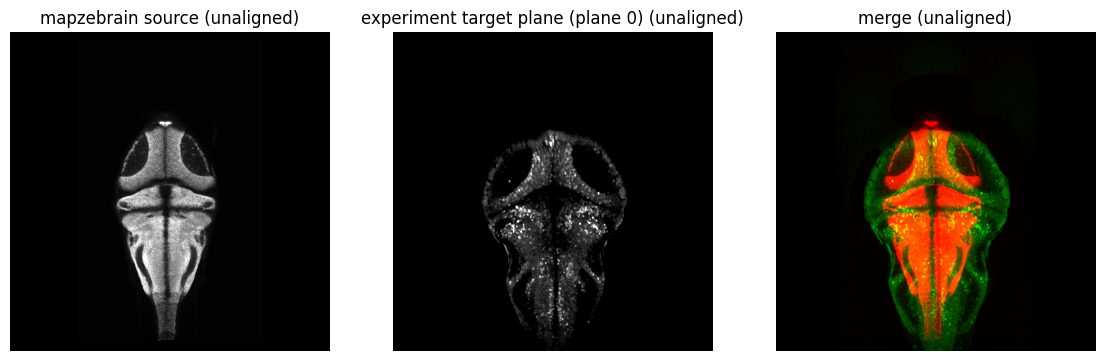

In [5]:
# Unaligned visualization: mapzebrain source, experiment target, RGB merge.
# (Left = `source_img`, center = `plot_img` — do not alias.)
#
# Requires: `source_img`, `plot_img`, `plane`.

# Intensity windows — same pattern as `3_brain_alignment_elysia.ipynb` (tune for display and for registration).
target_vmin = 100
target_vmax = 500
source_vmax = 1000

# Precomputed STD / projection TIFF: apply the same steps as `_std_plane_image` so shapes match `source_img` (1024² embedded).
external_std_tiff = Path(
    r"/Volumes/Kobi/DOI_animals_good/elavl3H2BGCaMP6s_9dpf_DOI_50ugml_15_20250925/mcorr_tiff_outputs/STD_mcorr_plane0_idx1_strides(160, 160)_overlaps(60, 60)_maxshifts(10, 10)_maxdev10-1.tif"
)
_raw = np.asarray(tifffile.imread(external_std_tiff), dtype=np.float64)
if _raw.ndim == 3:
    _raw = _raw[0]  # e.g. plane0 in filename; change index if you align another z-slice
elif _raw.ndim != 2:
    raise ValueError(f"Expected 2D or 3D array from STD tiff, got shape {_raw.shape}")
_m = float(np.nanmax(_raw))
plot_img = _raw
if _m > 0:
    plot_img = plot_img / _m
plot_img *= 2**10
plot_img = np.rot90(plot_img, k=1)
plot_img = sitkalignment.embed_image(plot_img, 1024)

fig, ax = plt.subplots(1, 3, figsize=(14, 6))
ax[0].imshow(source_img, cmap="gray", vmin=0, vmax=source_vmax)
ax[1].imshow(plot_img, cmap="gray", vmin=target_vmin, vmax=target_vmax)

merge = np.zeros((source_img.shape[0], source_img.shape[1], 3))
merge[:, :, 0] = 2 * source_img / max(float(source_img.max()), 1.0)
merge[:, :, 1] = 2 * plot_img / max(float(plot_img.max()), 1.0)
ax[2].imshow(merge)

ax[0].set_title("mapzebrain source (unaligned)")
ax[1].set_title(f"experiment target plane (plane 0) (unaligned)")
ax[2].set_title("merge (unaligned)")
for a in ax:
    a.axis("off")
plt.show()


In [7]:
%%time
# Primary alignment — same `minmax_scaler` + `register_image2` pattern as `3_brain_alignment_elysia.ipynb`.
# Elastix: fixed = experiment plane, moving = mapzebrain → warped atlas in experiment coordinates.
# Tune `target_vmin` / `target_vmax` / `source_vmax` in the unaligned visualization cell above.
# Geometry: mapzebrain slice = `selected_mapzebrain_z`; functional plane = `selected_plane`.
if "target_img_by_plane" in globals() and isinstance(target_img_by_plane, dict) and len(target_img_by_plane) > 0:
    if plane not in target_img_by_plane:
        raise ValueError(
            f"Plane {plane} not in target_img_by_plane. Available: {sorted(target_img_by_plane.keys())}"
        )

save_path = exp_folder.joinpath(f"alignment_rev_plane{plane}")

_reg_plot = minmax_scaler(plot_img, vmin=target_vmin, vmax=target_vmax)
_reg_source = minmax_scaler(source_img, vmin=0, vmax=source_vmax)

scale_penalties = [150]
iterations = [(10000, 500)]

registered_images = []
for sp in scale_penalties:
    for it in iterations:
        registered_image = sitkalignment.register_image2(
            _reg_plot, _reg_source, save_path, scalePenalty=sp, iterations=it
        )
        registered_images.append(registered_image)

NameError: name 'exp_folder' is not defined

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


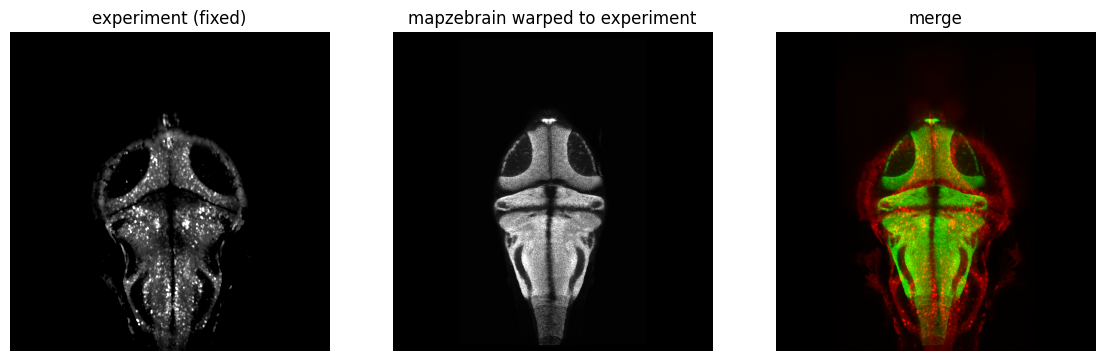

In [15]:
target_img = plot_img
for registered_image in registered_images:
	fig, ax = plt.subplots(1, 3, figsize=(14, 6))

	ax[0].imshow(
		target_img,
		cmap="gray",
		vmin=target_vmin,
		vmax=target_vmax,
	)
	ax[1].imshow(
		registered_image,
		cmap="gray",
		vmin=0,
		vmax=1000,
	)

	[a.axis("off") for a in ax]

	merge = np.zeros((target_img.shape[0], target_img.shape[1], 3))
	merge[:, :, 0] = 2 * target_img / max(float(target_img.max()), 1.0)
	merge[:, :, 1] = 1 * registered_image / max(float(registered_image.max()), 1.0)
	ax[-1].imshow(merge)

	ax[0].set_title("experiment (fixed)")
	ax[1].set_title("mapzebrain warped to experiment")
	ax[-1].set_title("merge")
	plt.show()

### Second alignment (experiment → atlas)

**Primary alignment** (cells above): matches `3_brain_alignment_elysia.ipynb` — `minmax_scaler` with `target_vmin` / `target_vmax` / `source_vmax`, then `register_image2(_reg_plot, _reg_source)` → **atlas warped to experiment** frame.

**Second alignment** (below): same `_reg_*` inputs but **`register_image2(_reg_source, _reg_plot)`** → **experiment warped to atlas** frame. Separate save folder.

Tuning (second alignment): edit `scale_penalties` and `iterations` in the next cell (same pattern as elysia).

In [8]:
%%time
# Experiment → atlas: fixed = mapzebrain, moving = experiment (same `_reg_*` as primary cell; swapped argument order).
# Prereq: run primary alignment cell so `_reg_source` / `_reg_plot` exist (or rebuild with minmax_scaler below).
if "_reg_plot" not in globals() or "_reg_source" not in globals():
    _reg_plot = minmax_scaler(plot_img, vmin=target_vmin, vmax=target_vmax)
    _reg_source = minmax_scaler(source_img, vmin=0, vmax=source_vmax)

if "target_img_by_plane" in globals() and isinstance(target_img_by_plane, dict) and len(target_img_by_plane) > 0:
    if plane not in target_img_by_plane:
        raise ValueError(
            f"Plane {plane} not in target_img_by_plane. Available: {sorted(target_img_by_plane.keys())}"
        )

save_path_exp_to_atlas = exp_folder.joinpath(f"alignment_exp_to_atlas_plane{plane}")

scale_penalties = [150]
iterations = [(10000, 500)]

registered_images_exp_to_atlas = []
for sp in scale_penalties:
    for it in iterations:
        warped_exp = sitkalignment.register_image2(
            _reg_source,
            _reg_plot,
            save_path_exp_to_atlas,
            scalePenalty=sp,
            iterations=it,
        )
        registered_images_exp_to_atlas.append(warped_exp)

ELASTIX version: 5.0.1
Command line options from ElastixBase:
-fMask    unspecified, so no fixed mask used
-mMask    unspecified, so no moving mask used
-out      ./
-threads  unspecified, so all available threads are used
  The default value "true" is used instead.

  From elastix 4.8 it defaults to true!
This may change the behavior of your registrations considerably.

Command line options from TransformBase:
-t0       unspecified, so no initial transform used

Reading images...
Reading images took 0 ms.

  A default pyramid schedule is used.
  A default pyramid schedule is used.
  The default value "false" is used instead.
  The default value "GeometricalCenter" is used instead.
Transform parameters are initialized as: [1, 0, 0, 1, 0, 0]
InitializeTransform took 0.00s
Scales are estimated automatically.
Scales for transform parameters are: [88400.25, 88400.25, 88400.25, 88400.25, 1, 1]
Initialization of all components (before registration) took: 2 ms.
Preparation of the image pyrami

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


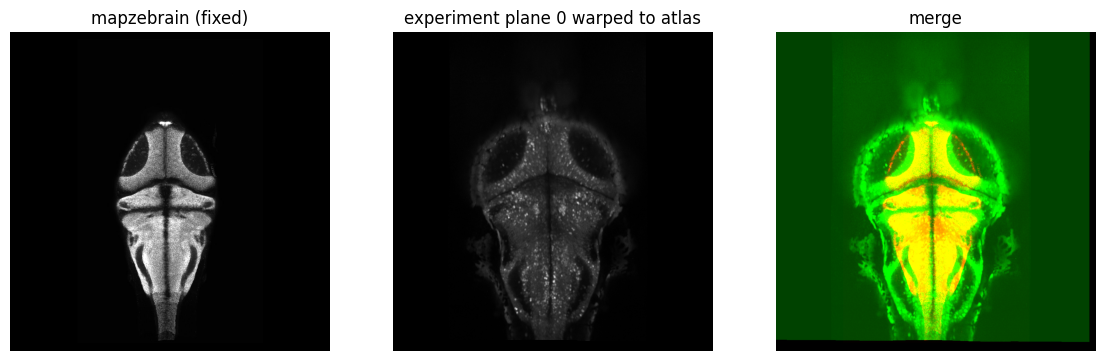

In [9]:
# QC: experiment warped to atlas space (fixed = mapzebrain during this registration)
for warped_exp in registered_images_exp_to_atlas:
    fig, ax = plt.subplots(1, 3, figsize=(14, 6))

    ax[0].imshow(source_img, cmap="gray", vmin=0, vmax=source_vmax)
    ax[1].imshow(warped_exp, cmap="gray", vmin=target_vmin, vmax=target_vmax)
    [a.axis("off") for a in ax]

    merge_e2a = np.zeros((source_img.shape[0], source_img.shape[1], 3))
    merge_e2a[:, :, 0] = 2 * source_img / max(float(source_img.max()), 1.0)
    merge_e2a[:, :, 1] = 4 * warped_exp / max(float(warped_exp.max()), 1.0)
    ax[2].imshow(merge_e2a)

    ax[0].set_title("mapzebrain (fixed)")
    ax[1].set_title(f"experiment plane {plane} warped to atlas")
    ax[2].set_title("merge")
    plt.show()